# PHASE 06: LOSS FUNCTION STUDY

Phase này nghiên cứu ảnh hưởng của các loss functions đối với bài toán PlantVillage classification khi dữ liệu train bị mất cân bằng nghiêm trọng.

Mục tiêu chính không chỉ là Accuracy, mà còn là Macro F1, Minority Recall và Worst-class Recall.


# 01. Thiết lập môi trường và import helper dùng chung

Tất cả pipeline dùng lại helper từ `src` để đảm bảo nhất quán với Phase 05: cùng split, cùng image size, cùng CNN architecture, cùng training loop và cùng EarlyStopping theo Validation Macro F1.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_DIR = Path('/Users/huynh/codes/kpdl/plan')
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.data import (
    ProjectPaths,
    ensure_directories,
    load_metadata,
    create_imbalanced_subset,
    create_stratified_subset,
    get_class_counts,
    get_num_classes,
    compute_inverse_frequency_weights,
    build_data_loader,
)
from src.models import get_simple_cnn
from src.train import FocalLoss, effective_number_class_weights, train_model, evaluate_model
from src.utils import (
    set_seed,
    get_device,
    get_pin_memory,
    get_num_workers,
    get_basic_transform,
    get_light_augmentation_transform,
    dataframe_to_markdown_safe,
    write_text_report,
)
from src.visualization import set_publication_style, annotate_bars

SEED = 42
set_seed(SEED)
set_publication_style()

DEVICE = get_device()
print(f'Thiết bị sử dụng: {DEVICE}')

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_DIR = PATHS.results_dir('06_loss_function_study')
REPORTS_DIR = PATHS.reports_dir('06_loss_function_study')
PHASE06_DIR = RESULTS_DIR / 'phase_06_loss_study'
PHASE06_FIGURE_DIR = PHASE06_DIR / 'figures'
PHASE06_TABLE_DIR = PHASE06_DIR / 'tables'
PHASE06_REPORT_DIR = PHASE06_DIR / 'reports'

ensure_directories(
    RESULTS_DIR,
    REPORTS_DIR,
    PHASE06_DIR,
    PHASE06_FIGURE_DIR,
    PHASE06_TABLE_DIR,
    PHASE06_REPORT_DIR,
    PHASE06_DIR / 'saved_models',
)

# Giữ cấu hình giống Phase 05 để so sánh công bằng.
USE_SUBSET = True
SUBSET_MAJORITY_FRACTION = 0.20
SUBSET_MINORITY_FRACTION = 0.45
SUBSET_THRESHOLD = 500
SUBSET_MIN_SAMPLES = 40
VAL_TEST_SUBSET_FRACTION = 0.30
VAL_TEST_MIN_SAMPLES = 8

IMAGE_SIZE = 128
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)

FORCE_TRAIN = True
EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
BATCH_SIZE = 64
LR = 1e-3
FOCAL_GAMMA = 2.0
CB_BETA = 0.999




Thiết bị sử dụng: mps


# 02. Nạp dữ liệu giống Phase 05

Để so sánh công bằng, Phase 06 dùng lại logic subset mất cân bằng của Phase 05. Như vậy khác biệt chính giữa các thí nghiệm là loss function, không phải split hoặc preprocessing.


In [2]:
train_df_raw, val_df_raw, test_df_raw, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)
class_names_list = class_map_df.sort_values('class_id')['class_name'].tolist()

if USE_SUBSET:
    train_df = create_imbalanced_subset(
        train_df_raw,
        majority_fraction=SUBSET_MAJORITY_FRACTION,
        minority_fraction=SUBSET_MINORITY_FRACTION,
        threshold=SUBSET_THRESHOLD,
        min_samples=SUBSET_MIN_SAMPLES,
        seed=SEED,
    )
    val_df = create_stratified_subset(
        val_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
    test_df = create_stratified_subset(
        test_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
else:
    train_df = train_df_raw.copy()
    val_df = val_df_raw.copy()
    test_df = test_df_raw.copy()

train_counts = get_class_counts(train_df)
imbalance_ratio = train_counts.max() / train_counts.min()
minority_threshold = train_counts.quantile(0.25)
minority_ids = train_counts[train_counts <= minority_threshold].index.tolist()

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'Số class: {NUM_CLASSES}')
print(f'Imbalance ratio: {imbalance_ratio:.2f}')
print(f'Minority threshold: {minority_threshold:.1f} samples')
print('Minority class IDs:', minority_ids)



Train: 9,383 | Val: 1,617 | Test: 1,618
Số class: 38
Imbalance ratio: 16.31
Minority threshold: 157.5 samples
Minority class IDs: [0, 2, 6, 9, 14, 17, 22, 23, 31, 36]


# 03. Transform và DataLoader

Loss study giữ augmentation strategy giống Phase 05: dùng light augmentation cho training và transform chuẩn cho validation/test. Điều này giúp giảm memorization nhưng không làm biến dạng triệu chứng bệnh trên lá.


In [3]:
train_transform = get_light_augmentation_transform(IMAGE_SIZE)
val_test_transform = get_basic_transform(IMAGE_SIZE)


def build_loss_study_loaders():
    """Tạo DataLoader mới cho từng experiment để seed/reproducibility sạch hơn."""
    train_loader = build_data_loader(
        train_df, BASE_DIR, 'color', train_transform,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(
        val_df, BASE_DIR, 'color', val_test_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    test_loader = build_data_loader(
        test_df, BASE_DIR, 'color', val_test_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader, test_loader


print('Đã định nghĩa DataLoader builder dùng chung cho Phase 06.')
print('Mỗi loss experiment sẽ tạo loader riêng sau khi set seed để so sánh công bằng hơn.')



Đã định nghĩa DataLoader builder dùng chung cho Phase 06.
Mỗi loss experiment sẽ tạo loader riêng sau khi set seed để so sánh công bằng hơn.


# 04. Tính class weights cho các loss functions

Weighted CE dùng inverse-frequency weights. Class-Balanced Loss dùng effective number of samples để tránh weight quá cực đoan ở các class rất ít mẫu.


In [4]:
inverse_weights = compute_inverse_frequency_weights(train_counts, num_classes=NUM_CLASSES)
class_balanced_weights = effective_number_class_weights(
    class_counts=train_counts,
    num_classes=NUM_CLASSES,
    beta=CB_BETA,
)

loss_weight_table = pd.DataFrame({
    'class_id': range(NUM_CLASSES),
    'class_name': class_names_list,
    'train_count': [int(train_counts.get(class_id, 0)) for class_id in range(NUM_CLASSES)],
    'inverse_frequency_weight': inverse_weights,
    'class_balanced_weight': class_balanced_weights,
    'is_minority': [class_id in minority_ids for class_id in range(NUM_CLASSES)],
})

loss_weight_table.to_csv(PHASE06_TABLE_DIR / 'loss_class_weights.csv', index=False)
display(loss_weight_table.sort_values('train_count').head(15))



,class_id,class_name,train_count,inverse_frequency_weight,class_balanced_weight,is_minority
22,22,Potato___healthy,54,3.335891,3.132920,True
2,2,Apple___Cedar_apple_rust,99,1.819577,1.747268,True
0,0,Apple___Apple_scab,100,1.801381,1.730646,True
17,17,Peach___healthy,129,1.396419,1.360814,True
23,23,Raspberry___healthy,133,1.354422,1.322473,True
36,36,Tomato___Tomato_mosaic_virus,134,1.344314,1.313246,True
6,6,Cherry_(including_sour)___healthy,136,1.324545,1.295200,True
31,31,Tomato___Leaf_Mold,152,1.185119,1.167951,True
14,14,Grape___healthy,152,1.185119,1.167951,True
9,9,Corn_(maize)___Northern_Leaf_Blight,157,1.147376,1.133514,True


# 05. Khởi tạo loss functions

Các loss được so sánh:

- `ce_baseline`: CrossEntropyLoss chuẩn.
- `weighted_ce`: CrossEntropyLoss có class weights.
- `focal_loss`: tập trung hơn vào hard samples.
- `class_balanced_loss`: dùng effective number theory để tính trọng số class.


In [5]:
def build_loss_functions():
    """Khởi tạo loss functions cho Phase 06."""
    inverse_weight_tensor = torch.FloatTensor(inverse_weights).to(DEVICE)
    cb_weight_tensor = torch.FloatTensor(class_balanced_weights).to(DEVICE)

    # FocalLoss hỗ trợ tham số weight. Ở experiment chính, weight=None để tách riêng
    # ảnh hưởng của focal mechanism khỏi class weighting.
    return {
        'ce_baseline': nn.CrossEntropyLoss(),
        'weighted_ce': nn.CrossEntropyLoss(weight=inverse_weight_tensor),
        'focal_loss': FocalLoss(gamma=FOCAL_GAMMA, weight=None),
        'class_balanced_loss': nn.CrossEntropyLoss(weight=cb_weight_tensor),
    }


LOSS_FUNCTIONS = build_loss_functions()
print('Loss functions:', list(LOSS_FUNCTIONS.keys()))
print(f'Focal gamma = {FOCAL_GAMMA}')
print(f'Class-Balanced beta = {CB_BETA}')



Loss functions: ['ce_baseline', 'weighted_ce', 'focal_loss', 'class_balanced_loss']
Focal gamma = 2.0
Class-Balanced beta = 0.999


# 06. Hàm chạy một loss experiment

Mỗi experiment train độc lập, lưu checkpoint riêng và đánh giá trên cùng test set. EarlyStopping vẫn dựa trên Validation Macro F1 như Phase 05.


In [6]:
loss_experiment_results = {}
loss_training_histories = {}


def run_loss_experiment(exp_name, criterion):
    """Train và evaluate một loss function experiment."""
    set_seed(SEED)
    train_loader, val_loader, test_loader = build_loss_study_loaders()

    save_path = PHASE06_DIR / 'saved_models' / f'{exp_name}_{IMAGE_SIZE}px_best.pth'
    model = get_simple_cnn(num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    print('\n' + '=' * 70)
    print(f'LOSS EXPERIMENT: {exp_name}')
    print('=' * 70)
    print(f'Epochs={EPOCHS} | Patience={EARLY_STOPPING_PATIENCE} | Monitor=Validation Macro F1')

    if (not FORCE_TRAIN) and save_path.exists():
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
        history = None
        print(f'Đã nạp checkpoint: {save_path}')
    else:
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            epochs=EPOCHS,
            device=DEVICE,
            save_path=save_path,
            patience=EARLY_STOPPING_PATIENCE,
            use_early_stopping=True,
        )
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))

    result = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)
    loss_experiment_results[exp_name] = result
    if history is not None:
        loss_training_histories[exp_name] = history

    print(
        f"[RESULT {exp_name}] "
        f"Acc={result['accuracy']:.4f} | "
        f"Macro F1={result['macro_f1']:.4f} | "
        f"Macro Recall={result['recall']:.4f}"
    )
    return result



# 07. Chạy các loss experiments

Cell này có thể tốn thời gian vì mỗi loss function được train độc lập. Nếu đã có checkpoint, có thể đặt `FORCE_TRAIN = False` ở cell setup để load lại.


In [7]:
for experiment_name, criterion in LOSS_FUNCTIONS.items():
    run_loss_experiment(experiment_name, criterion)




LOSS EXPERIMENT: ce_baseline
Epochs=15 | Patience=3 | Monitor=Validation Macro F1
Epoch 01/15 | Train Loss: 2.7796 | Val Loss: 2.0552 | Val Acc: 0.4706 | Val Macro F1: 0.2195
Epoch 02/15 | Train Loss: 1.9853 | Val Loss: 1.5486 | Val Acc: 0.5523 | Val Macro F1: 0.3606
Epoch 03/15 | Train Loss: 1.6139 | Val Loss: 1.1972 | Val Acc: 0.6506 | Val Macro F1: 0.5125
Epoch 04/15 | Train Loss: 1.4020 | Val Loss: 1.1142 | Val Acc: 0.6469 | Val Macro F1: 0.5272
Epoch 05/15 | Train Loss: 1.2391 | Val Loss: 1.0376 | Val Acc: 0.6889 | Val Macro F1: 0.5857
Epoch 06/15 | Train Loss: 1.1467 | Val Loss: 0.9031 | Val Acc: 0.7260 | Val Macro F1: 0.6268
Epoch 07/15 | Train Loss: 1.0311 | Val Loss: 0.7751 | Val Acc: 0.7675 | Val Macro F1: 0.6921
Epoch 08/15 | Train Loss: 0.9497 | Val Loss: 0.6653 | Val Acc: 0.7873 | Val Macro F1: 0.7280
Epoch 09/15 | Train Loss: 0.8918 | Val Loss: 0.6828 | Val Acc: 0.7805 | Val Macro F1: 0.6970
Epoch 10/15 | Train Loss: 0.8120 | Val Loss: 0.5717 | Val Acc: 0.8219 | Val Macr

# 08. Tổng hợp quantitative results

Bảng này tập trung vào trade-off giữa Accuracy và fairness metrics. Với severe imbalance, Macro F1, Minority Recall và Worst-class Recall thường quan trọng hơn Accuracy đơn lẻ.


In [8]:
def summarize_loss_results(results):
    records = []
    for experiment_name, result in results.items():
        minority_recall = np.mean([result['per_class_recall'][class_id] for class_id in minority_ids])
        worst_class_recall = np.min(result['per_class_recall'])
        records.append({
            'Experiment': experiment_name,
            'Accuracy': result['accuracy'],
            'Macro Precision': result['precision'],
            'Macro Recall': result['recall'],
            'Macro F1': result['macro_f1'],
            'Minority Recall': minority_recall,
            'Worst-class Recall': worst_class_recall,
        })
    return pd.DataFrame(records).sort_values('Macro F1', ascending=False).reset_index(drop=True)


def build_per_class_loss_metrics(results):
    """Lưu Recall/F1 theo từng class cho từng loss function."""
    records = []
    for experiment_name, result in results.items():
        for class_id in range(NUM_CLASSES):
            records.append({
                'Experiment': experiment_name,
                'Class_ID': class_id,
                'Class': class_names_list[class_id],
                'Train Sample Count': int(train_counts.get(class_id, 0)),
                'Is Minority': class_id in minority_ids,
                'Per-class Recall': result['per_class_recall'][class_id],
                'Per-class F1': result['per_class_f1'][class_id],
            })
    return pd.DataFrame(records)


loss_summary_df = summarize_loss_results(loss_experiment_results)
loss_summary_df.to_csv(PHASE06_TABLE_DIR / 'loss_function_comparison.csv', index=False)

per_class_loss_metrics_df = build_per_class_loss_metrics(loss_experiment_results)
per_class_loss_metrics_df.to_csv(PHASE06_TABLE_DIR / 'per_class_recall_f1_by_loss.csv', index=False)

display(loss_summary_df)
print('Per-class metrics sample:')
display(per_class_loss_metrics_df.head(12))

best_minority_exp = loss_summary_df.sort_values('Minority Recall', ascending=False).iloc[0]['Experiment']
best_fairness_exp = loss_summary_df.sort_values(['Worst-class Recall', 'Macro F1'], ascending=False).iloc[0]['Experiment']
best_tradeoff_exp = loss_summary_df.sort_values(['Macro F1', 'Minority Recall'], ascending=False).iloc[0]['Experiment']

print(f'Best minority performance: {best_minority_exp}')
print(f'Best fairness: {best_fairness_exp}')
print(f'Best overall trade-off: {best_tradeoff_exp}')



,Experiment,Accuracy,Macro Precision,Macro Recall,Macro F1,Minority Recall,Worst-class Recall
0,class_balanced_loss,0.832509,0.775059,0.845858,0.795935,0.886295,0.452830
1,focal_loss,0.834363,0.818876,0.799888,0.795813,0.807267,0.366667
2,ce_baseline,0.836218,0.798178,0.809228,0.783917,0.818854,0.266667
3,weighted_ce,0.759580,0.713443,0.759937,0.710292,0.793740,0.350877


Per-class metrics sample:


,Experiment,Class_ID,Class,Train Sample Count,Is Minority,Per-class Recall,Per-class F1
0,ce_baseline,0,Apple___Apple_scab,100,True,0.500000,0.486486
1,ce_baseline,1,Apple___Black_rot,223,False,1.000000,0.692308
2,ce_baseline,2,Apple___Cedar_apple_rust,99,True,0.750000,0.705882
3,ce_baseline,3,Apple___healthy,263,False,0.612245,0.731707
4,ce_baseline,4,Blueberry___healthy,240,False,0.977778,0.862745
5,ce_baseline,5,Cherry_(including_sour)___Powdery_mildew,168,False,0.838710,0.825397
6,ce_baseline,6,Cherry_(including_sour)___healthy,136,True,0.840000,0.875000
7,ce_baseline,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,184,False,0.933333,0.823529
8,ce_baseline,8,Corn_(maize)___Common_rust_,190,False,0.972222,0.972222
9,ce_baseline,9,Corn_(maize)___Northern_Leaf_Blight,157,True,0.862069,0.877193


Best minority performance: class_balanced_loss
Best fairness: class_balanced_loss
Best overall trade-off: class_balanced_loss


# 09. Visualization: so sánh metric giữa các loss functions

Bar chart giúp nhìn nhanh loss nào tối ưu Accuracy, loss nào cải thiện fairness metrics. Nếu Accuracy giảm nhưng Minority Recall tăng, đó có thể là trade-off hợp lý trong bài toán imbalance.


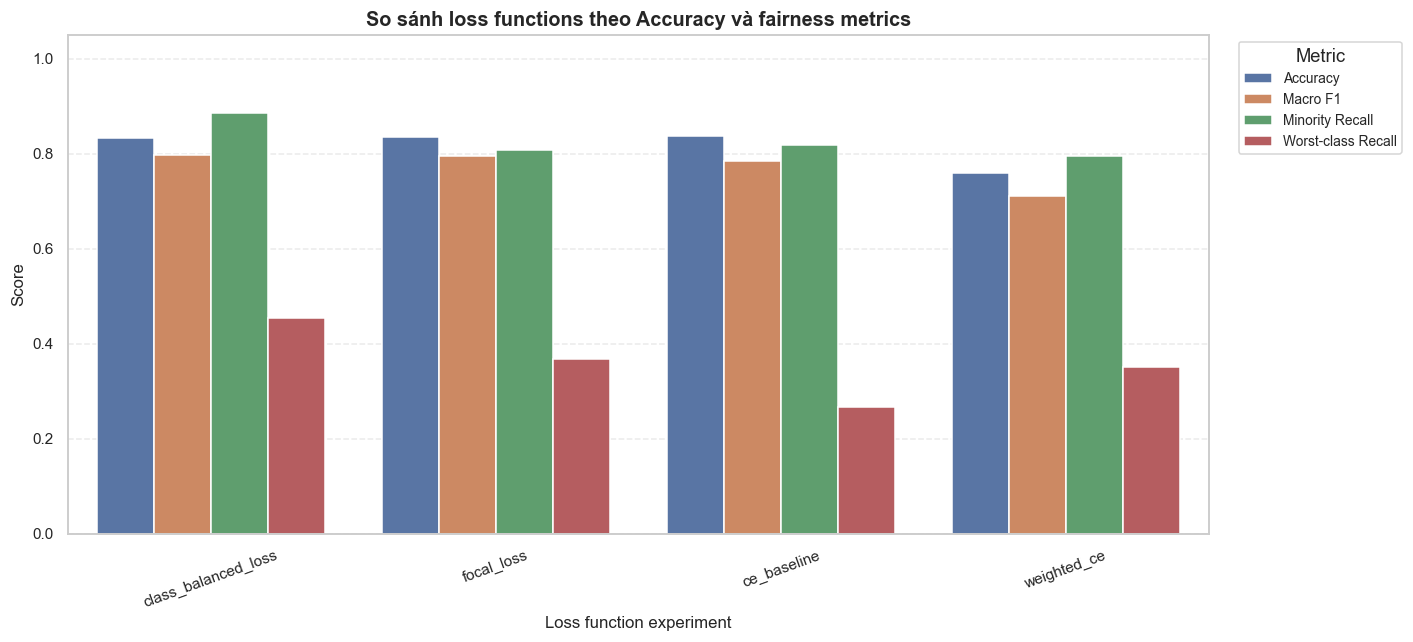

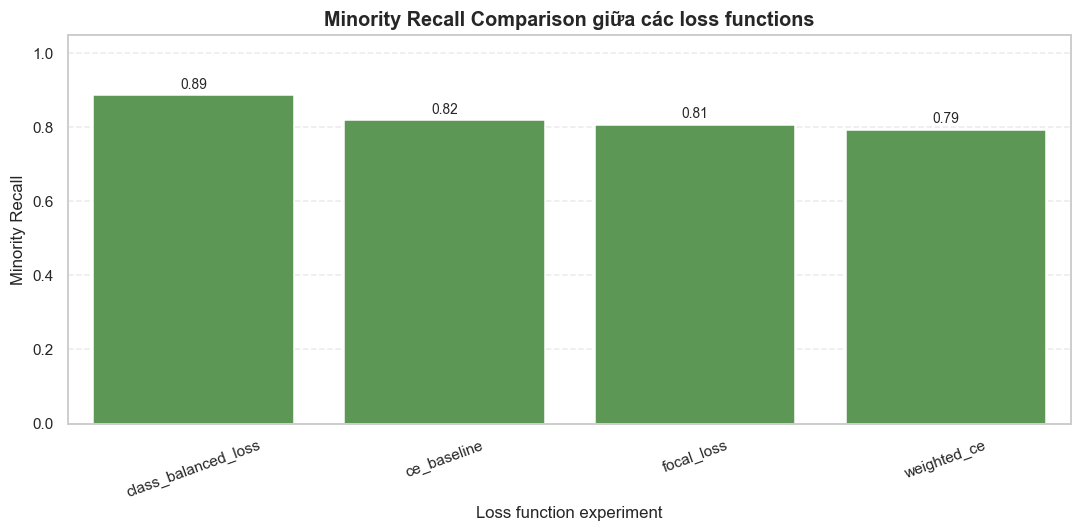

In [9]:
metric_columns = ['Accuracy', 'Macro F1', 'Minority Recall', 'Worst-class Recall']
plot_df = loss_summary_df.melt(
    id_vars='Experiment',
    value_vars=metric_columns,
    var_name='Metric',
    value_name='Score',
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_df, x='Experiment', y='Score', hue='Metric')
ax.set_title('So sánh loss functions theo Accuracy và fairness metrics', fontweight='bold')
ax.set_xlabel('Loss function experiment')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PHASE06_FIGURE_DIR / 'loss_metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=loss_summary_df.sort_values('Minority Recall', ascending=False),
    x='Experiment',
    y='Minority Recall',
    color='#54A24B',
)
ax.set_title('Minority Recall Comparison giữa các loss functions', fontweight='bold')
ax.set_xlabel('Loss function experiment')
ax.set_ylabel('Minority Recall')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)
annotate_bars(ax)
plt.tight_layout()
plt.savefig(PHASE06_FIGURE_DIR / 'minority_recall_by_loss.png', dpi=300, bbox_inches='tight')
plt.show()



# 10. Per-class Recall heatmap

Heatmap cho biết loss nào cải thiện từng class cụ thể. Đây là biểu đồ quan trọng vì imbalance thường chỉ ảnh hưởng mạnh đến một số class thiểu số.


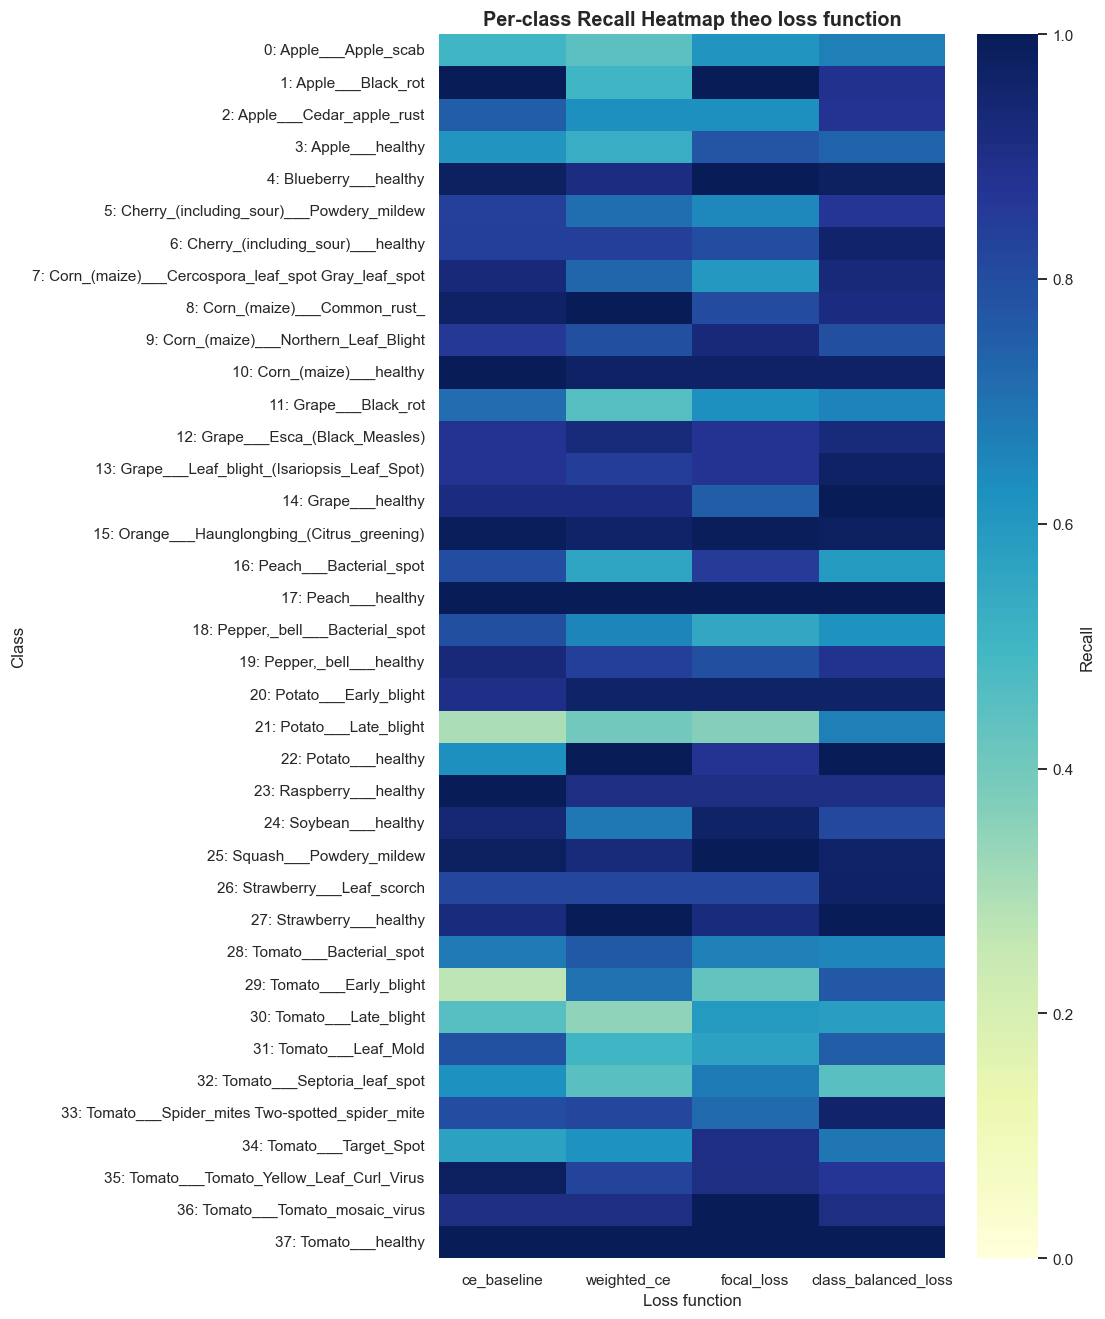

In [10]:
recall_heatmap_df = pd.DataFrame({
    experiment_name: result['per_class_recall']
    for experiment_name, result in loss_experiment_results.items()
})
recall_heatmap_df.index = [f'{class_id}: {class_names_list[class_id]}' for class_id in range(NUM_CLASSES)]
recall_heatmap_df.to_csv(PHASE06_TABLE_DIR / 'per_class_recall_by_loss.csv')

plt.figure(figsize=(10, max(10, NUM_CLASSES * 0.32)))
sns.heatmap(recall_heatmap_df, cmap='YlGnBu', vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
plt.title('Per-class Recall Heatmap theo loss function', fontweight='bold')
plt.xlabel('Loss function')
plt.ylabel('Class')
plt.tight_layout()
plt.savefig(PHASE06_FIGURE_DIR / 'per_class_recall_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



# 11. Loss convergence analysis

Learning curves giúp đánh giá tốc độ hội tụ và dấu hiệu overfitting. Nếu train loss giảm nhưng Validation Macro F1 không tăng, loss đó có thể đang học lệch hoặc overfit.


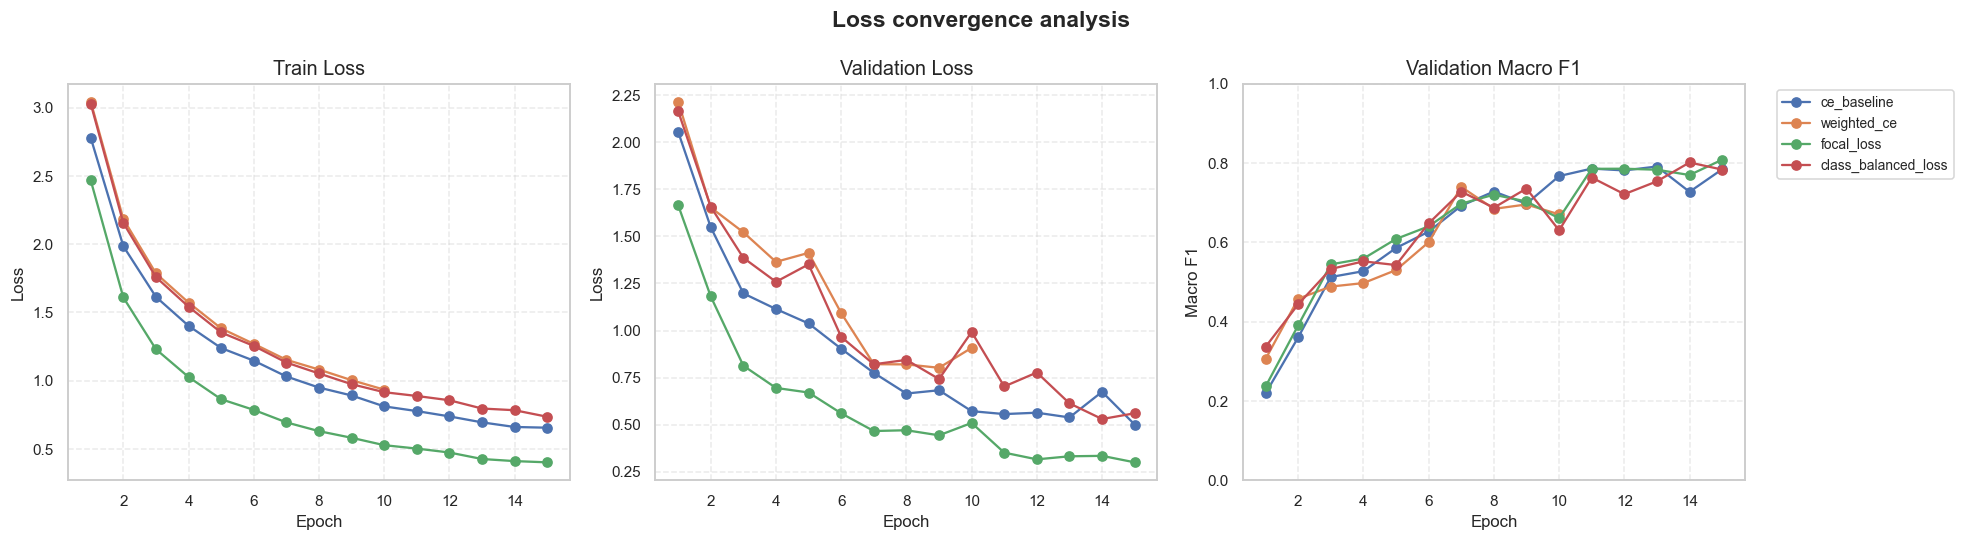

In [11]:
if len(loss_training_histories) == 0:
    print('Không có training history. Nếu load từ checkpoint thì curves sẽ không có.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for experiment_name, history in loss_training_histories.items():
        epochs_range = range(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs_range, history['train_loss'], marker='o', label=experiment_name)
        axes[1].plot(epochs_range, history['val_loss'], marker='o', label=experiment_name)
        axes[2].plot(epochs_range, history['val_f1'], marker='o', label=experiment_name)

    axes[0].set_title('Train Loss')
    axes[1].set_title('Validation Loss')
    axes[2].set_title('Validation Macro F1')

    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.grid(True, linestyle='--', alpha=0.4)

    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Loss')
    axes[2].set_ylabel('Macro F1')
    axes[2].set_ylim(0, 1)
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.suptitle('Loss convergence analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PHASE06_FIGURE_DIR / 'loss_convergence_curves.png', dpi=300, bbox_inches='tight')
    plt.show()



# 12. Hard sample analysis

Bảng này so sánh Recall theo class giữa CrossEntropy baseline và Focal Loss. Mục tiêu là xem Focal Loss có giúp học các hard minority samples tốt hơn không.


In [12]:
if 'ce_baseline' in loss_experiment_results and 'focal_loss' in loss_experiment_results:
    ce_recall = loss_experiment_results['ce_baseline']['per_class_recall']
    focal_recall = loss_experiment_results['focal_loss']['per_class_recall']
    ce_f1 = loss_experiment_results['ce_baseline']['per_class_f1']
    focal_f1 = loss_experiment_results['focal_loss']['per_class_f1']

    hard_sample_df = pd.DataFrame({
        'Class_ID': range(NUM_CLASSES),
        'Class': class_names_list,
        'Train Sample Count': [int(train_counts.get(class_id, 0)) for class_id in range(NUM_CLASSES)],
        'Is Minority': [class_id in minority_ids for class_id in range(NUM_CLASSES)],
        'CE Recall': ce_recall,
        'Focal Recall': focal_recall,
        'Recall Improvement': focal_recall - ce_recall,
        'CE F1': ce_f1,
        'Focal F1': focal_f1,
        'F1 Improvement': focal_f1 - ce_f1,
    }).sort_values('Recall Improvement', ascending=False)

    hard_sample_df.to_csv(PHASE06_TABLE_DIR / 'ce_vs_focal_hard_sample_analysis.csv', index=False)

    print('Top class cải thiện Recall mạnh nhất khi dùng Focal Loss:')
    display(hard_sample_df.head(15))

    print('Các class vẫn fail dưới Focal Loss:')
    display(hard_sample_df.sort_values('Focal Recall').head(10))
else:
    print('Cần có cả ce_baseline và focal_loss để phân tích hard samples.')



Top class cải thiện Recall mạnh nhất khi dùng Focal Loss:


,Class_ID,Class,Train Sample Count,Is Minority,CE Recall,Focal Recall,Recall Improvement,CE F1,Focal F1,F1 Improvement
34,34,Tomato___Target_Spot,224,False,0.571429,0.904762,0.333333,0.685714,0.775510,0.089796
22,22,Potato___healthy,54,True,0.625000,0.875000,0.250000,0.666667,0.933333,0.266667
29,29,Tomato___Early_blight,160,False,0.266667,0.433333,0.166667,0.410256,0.590909,0.180653
3,3,Apple___healthy,263,False,0.612245,0.775510,0.163265,0.731707,0.745098,0.013391
30,30,Tomato___Late_blight,305,False,0.456140,0.596491,0.140351,0.553191,0.557377,0.004186
0,0,Apple___Apple_scab,100,True,0.500000,0.611111,0.111111,0.486486,0.666667,0.180180
36,36,Tomato___Tomato_mosaic_virus,134,True,0.909091,1.000000,0.090909,0.540541,0.758621,0.218080
9,9,Corn_(maize)___Northern_Leaf_Blight,157,True,0.862069,0.931034,0.068966,0.877193,0.782609,-0.094584
21,21,Potato___Late_blight,160,False,0.300000,0.366667,0.066667,0.450000,0.488889,0.038889
20,20,Potato___Early_blight,160,False,0.900000,0.966667,0.066667,0.857143,0.763158,-0.093985


Các class vẫn fail dưới Focal Loss:


,Class_ID,Class,Train Sample Count,Is Minority,CE Recall,Focal Recall,Recall Improvement,CE F1,Focal F1,F1 Improvement
21,21,Potato___Late_blight,160,False,0.300000,0.366667,0.066667,0.450000,0.488889,0.038889
29,29,Tomato___Early_blight,160,False,0.266667,0.433333,0.166667,0.410256,0.590909,0.180653
18,18,"Pepper,_bell___Bacterial_spot",159,False,0.793103,0.551724,-0.241379,0.621622,0.653061,0.031440
31,31,Tomato___Leaf_Mold,152,True,0.785714,0.571429,-0.214286,0.771930,0.666667,-0.105263
30,30,Tomato___Late_blight,305,False,0.456140,0.596491,0.140351,0.553191,0.557377,0.004186
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,184,False,0.933333,0.600000,-0.333333,0.823529,0.600000,-0.223529
0,0,Apple___Apple_scab,100,True,0.500000,0.611111,0.111111,0.486486,0.666667,0.180180
2,2,Apple___Cedar_apple_rust,99,True,0.750000,0.625000,-0.125000,0.705882,0.666667,-0.039216
11,11,Grape___Black_rot,188,False,0.714286,0.628571,-0.085714,0.704225,0.709677,0.005452
5,5,Cherry_(including_sour)___Powdery_mildew,168,False,0.838710,0.645161,-0.193548,0.825397,0.784314,-0.041083


# 13. Discussion và xuất báo cáo

Discussion tập trung vào loss-level imbalance handling và trade-off giữa Accuracy với các fairness metrics.


In [13]:
best_macro_f1_exp = loss_summary_df.sort_values('Macro F1', ascending=False).iloc[0]['Experiment']
best_minority_exp = loss_summary_df.sort_values('Minority Recall', ascending=False).iloc[0]['Experiment']

report_sections = []
report_sections.append('# Báo cáo Phase 06: Loss Function Study')
report_sections.append(f'Thời điểm tạo báo cáo: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}')
report_sections.append('')
report_sections.append('## 1. Methodology')
report_sections.append('Phase 06 giữ nguyên split, image size, SimpleCNN architecture, light augmentation và EarlyStopping theo Validation Macro F1 như Phase 05. Khác biệt chính giữa các thí nghiệm là loss function.')
report_sections.append('')
report_sections.append('## 2. Loss functions')
report_sections.append('- CrossEntropyLoss: baseline loss không weighting.')
report_sections.append('- Weighted CrossEntropyLoss: tăng penalty cho class thiểu số bằng inverse-frequency weights.')
report_sections.append('- Focal Loss: tập trung vào hard samples bằng hệ số `(1 - pt)^gamma`.')
report_sections.append('- Class-Balanced Loss: dùng effective number of samples để tính class weights ổn định hơn.')
report_sections.append('')
report_sections.append('## 3. Quantitative results')
report_sections.append(dataframe_to_markdown_safe(loss_summary_df))
report_sections.append('')
report_sections.append('## 4. Per-class metrics')
report_sections.append('Bảng per-class Recall/F1 đầy đủ được lưu tại `tables/per_class_recall_f1_by_loss.csv`. Đây là bảng dùng để kiểm tra class nào hưởng lợi hoặc suy giảm dưới từng loss function.')
report_sections.append('')
report_sections.append('## 5. Discussion')
report_sections.append('CrossEntropyLoss thường bị bias về majority classes vì phần lớn gradient đến từ các class có nhiều mẫu. Weighted CE cải thiện sensitivity với minority classes, nhưng weight quá lớn có thể làm training kém ổn định. Focal Loss chuyển trọng tâm từ easy majority samples sang hard samples, nên có tiềm năng cải thiện các class khó học. Class-Balanced Loss dựa trên effective number theory, nhờ đó xử lý imbalance mềm hơn inverse-frequency weighting thuần túy.')
report_sections.append('')
report_sections.append(f'Experiment có Macro F1 tốt nhất là `{best_macro_f1_exp}`. Experiment có Minority Recall tốt nhất là `{best_minority_exp}`. Nếu Accuracy giảm nhẹ nhưng Macro F1, Minority Recall hoặc Worst-class Recall tăng, đây là trade-off có ý nghĩa trong bối cảnh severe class imbalance.')
report_sections.append('')
report_sections.append('Loss-level balancing khác sampler-based balancing: loss-level thay đổi hàm mục tiêu tối ưu, trong khi sampler-based thay đổi xác suất xuất hiện của mẫu trong mini-batch. Vì vậy hai hướng này trả lời hai câu hỏi nghiên cứu khác nhau và có thể được so sánh hoặc kết hợp ở các phase sau.')
report_sections.append('')
report_sections.append('## 6. Conclusions')
report_sections.append('- Accuracy không đủ để đánh giá model trong dữ liệu mất cân bằng nghiêm trọng.')
report_sections.append('- Macro F1, Minority Recall và Worst-class Recall phản ánh tốt hơn khả năng nhận diện minority classes.')
report_sections.append('- Weighted CE và Class-Balanced Loss xử lý imbalance bằng class weights.')
report_sections.append('- Focal Loss tập trung vào hard samples và có thể hỗ trợ class khó học.')
report_sections.append('- Loss function study cung cấp góc nhìn bổ sung cho sampler/resampling study ở Phase 05.')

report_text = '\n'.join(report_sections)
write_text_report(PHASE06_REPORT_DIR / 'loss_function_study_report.md', report_sections)
write_text_report(PHASE06_REPORT_DIR / 'loss_function_study_report.txt', report_sections)

print(report_text)
print(f"Đã lưu report tại: {PHASE06_REPORT_DIR}")




# Báo cáo Phase 06: Loss Function Study
Thời điểm tạo báo cáo: 2026-05-24 11:05:30

## 1. Methodology
Phase 06 giữ nguyên split, image size, SimpleCNN architecture, light augmentation và EarlyStopping theo Validation Macro F1 như Phase 05. Khác biệt chính giữa các thí nghiệm là loss function.

## 2. Loss functions
- CrossEntropyLoss: baseline loss không weighting.
- Weighted CrossEntropyLoss: tăng penalty cho class thiểu số bằng inverse-frequency weights.
- Focal Loss: tập trung vào hard samples bằng hệ số `(1 - pt)^gamma`.
- Class-Balanced Loss: dùng effective number of samples để tính class weights ổn định hơn.

## 3. Quantitative results
         Experiment  Accuracy  Macro Precision  Macro Recall  Macro F1  Minority Recall  Worst-class Recall
class_balanced_loss  0.832509         0.775059      0.845858  0.795935         0.886295            0.452830
         focal_loss  0.834363         0.818876      0.799888  0.795813         0.807267            0.366667
        ce_baseline  0.8362